# Neural Machine Translation: English → Amharic
### Basic Seq2Seq (LSTM) vs. Attention-Based Seq2Seq (LSTM)



End-to-end: corpus collection → cleaning → tokenizer → two models → resumable training (checkpoints on Drive) → BLEU/chrF eval → error analysis → attention heatmaps → FastAPI + Gradio deployment → submission ZIP.

### Group Member
1. Ahmed Hussen
2. Tekilu Assefa


# Install Package and Import Library

In [3]:
!pip install -q datasets==2.19.0 sentencepiece sacrebleu==2.4.2 fastapi uvicorn gradio nest_asyncio tabulate scikit-learn

import os, re, time, json, math, random, unicodedata, zipfile, subprocess, glob, sys
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import sentencepiece as spm
import sacrebleu
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

WORKDIR = "/content/nmt_project"
for sub in ["data", "tokenizer", "checkpoints", "deploy", "raw"]:
    os.makedirs(f"{WORKDIR}/{sub}", exist_ok=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 13.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2024.3.1 which is incompatible.
Device: cuda


# Mount drive


In [4]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR = "/content/drive/MyDrive/nmt_project_checkpoints"
os.makedirs(DRIVE_DIR, exist_ok=True)
print("Checkpoints will be saved to:", DRIVE_DIR)


Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/nmt_project_checkpoints


# Load dataset

In [5]:
from datasets import load_dataset

def _add(S, T, tag):
    n = min(len(S), len(T))
    all_src.extend(S[:n]); all_tgt.extend(T[:n]); all_tag.extend([tag] * n)
    print(f"  + {tag}: {n}")

all_src, all_tgt, all_tag = [], [], []

print("Collecting OPUS-100 (am-en)...")
try:
    raw = load_dataset("Helsinki-NLP/opus-100", "am-en")
    for s in ["train", "validation", "test"]:
        ex = raw[s]["translation"]
        _add([e["en"] for e in ex], [e["am"] for e in ex], "opus-100")
except Exception as e:
    print("  skipped:", e)

print("Collecting adtsegaye corpus...")
dest = f"{WORKDIR}/raw/adtsegaye"
if not os.path.exists(dest):
    subprocess.run(["git", "clone", "--depth", "1",
        "https://github.com/adtsegaye/Amharic-English-Machine-Translation-Corpus.git",
        dest], capture_output=True)
if os.path.exists(f"{dest}/en.txt"):
    en_ = open(f"{dest}/en.txt", encoding="utf-8").read().splitlines()
    am_ = open(f"{dest}/am.txt", encoding="utf-8").read().splitlines()
    _add(en_, am_, "adtsegaye")

print("Collecting Gezmu et al. 2022...")
gz = f"{WORKDIR}/raw/gezmu.zip"
if not os.path.exists(gz):
    subprocess.run(["wget", "-q", "-O", gz,
        "http://wwwiti.cs.uni-magdeburg.de/iti_dke/Datasets/Amharic%E2%80%93English_Parallel_Corpus-version_1.0.zip"],
        capture_output=True)
if os.path.exists(gz):
    try:
        with zipfile.ZipFile(gz) as zf:
            zf.extractall(f"{WORKDIR}/raw/gezmu")
        gez_en, gez_am = [], []
        for ep in sorted(glob.glob(f"{WORKDIR}/raw/gezmu/**/*.am-en.base.en", recursive=True)):
            ap = ep[:-3] + ".am"
            if os.path.exists(ap):
                gez_en += open(ep, encoding="utf-8", errors="ignore").read().splitlines()
                gez_am += open(ap, encoding="utf-8", errors="ignore").read().splitlines()
        if gez_en:
            _add(gez_en, gez_am, "gezmu2022")
    except Exception as e:
        print("  skipped:", e)

for path, ec, ac, tag, cap in [
    ("/content/drive/MyDrive/english_amharic_10k_sentences.csv", "text", "translation", "new_10k", None),
    ("/content/drive/MyDrive/amharic_english_clean_excel.csv", "english", "amharic", "quran_jw_196k", 40000),
]:
    if os.path.exists(path):
        df = pd.read_csv(path, encoding="utf-8-sig")
        en_, am_ = df[ec].astype(str).tolist(), df[ac].astype(str).tolist()
        if cap and len(en_) > cap:
            rng = random.Random(SEED)
            idx = rng.sample(range(len(en_)), cap)
            en_ = [en_[i] for i in idx]; am_ = [am_[i] for i in idx]
        _add(en_, am_, tag)

print(f"\nRaw total: {len(all_src)} | {dict(Counter(all_tag))}")


Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/89027 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  + opus-100: 89027
  + opus-100: 2000
  + opus-100: 2000
  + adtsegaye: 56044
  + gezmu2022: 145364
  + new_10k: 10200
  + quran_jw_196k: 40000

Raw total: 344635 | {'opus-100': 93027, 'adtsegaye': 56044, 'gezmu2022': 145364, 'new_10k': 10200, 'quran_jw_196k': 40000}


# Data Processing

In [6]:
from sklearn.model_selection import train_test_split

seen = set(); merged_src, merged_tgt = [], []
for s, t in zip(all_src, all_tgt):
    s, t = s.strip(), t.strip()
    if not s or not t or (s, t) in seen:
        continue
    seen.add((s, t)); merged_src.append(s); merged_tgt.append(t)
print(f"After dedup: {len(merged_src)}")

tr_s_raw, tmp_s, tr_t_raw, tmp_t = train_test_split(
    merged_src, merged_tgt, test_size=0.2, random_state=SEED)
va_s_raw, te_s, va_t_raw, te_t = train_test_split(
    tmp_s, tmp_t, test_size=0.5, random_state=SEED)

MIN_LEN, MAX_LEN = 2, 60
MAX_TRAIN_PAIRS = 150000

UI_RE = re.compile("|".join([
    r"_[A-Za-z\u1200-\u137F]",
    r"\(_[A-Za-z]\)",
    r"%[sd]\b",
    r"%[HMS]\b",
    r"<<[^>]+>>",
    r"_BAR_",
    r"\b[a-z]+-[a-z]+-[a-z-]+\b",
]))
BAD_PHRASES = ["abbreviated", "ordinal number", "is the ordinal",
               'like "third"', "time division", "placeholder", "do not translate"]

def has_ui(t):
    return bool(UI_RE.search(t)) or any(p in t.lower() for p in BAD_PHRASES)

def has_mix(t):
    return bool(re.search(r"[\u1200-\u137F][A-Za-z]{2,}", t)) or \
           bool(re.search(r"[A-Za-z]{2,}[\u1200-\u137F]", t))

def has_geez(t):
    return bool(re.search(r"[ሀ-፿]", t))

def norm(s):
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", s)).strip()

def clean(S, T, cap=None):
    seen = set(); so, to = [], []
    for s, t in zip(S, T):
        s, t = norm(s), norm(t)
        if not s or not t:
            continue
        if has_ui(s) or has_ui(t) or has_mix(t) or not has_geez(t):
            continue
        ns, nt = len(s.split()), len(t.split())
        if not (MIN_LEN <= ns <= MAX_LEN) or not (MIN_LEN <= nt <= MAX_LEN):
            continue
        if (s, t) in seen:
            continue
        seen.add((s, t)); so.append(s); to.append(t)
        if cap and len(so) >= cap:
            break
    return so, to

tr_s, tr_t = clean(tr_s_raw, tr_t_raw, MAX_TRAIN_PAIRS)
va_s, va_t = clean(va_s_raw, va_t_raw)
te_s, te_t = clean(te_s, te_t)
print(f"Clean -> train={len(tr_s)} val={len(va_s)} test={len(te_s)}")

for name, S, T in [("train", tr_s, tr_t), ("val", va_s, va_t), ("test", te_s, te_t)]:
    open(f"{WORKDIR}/data/{name}.en", "w").write("\n".join(S))
    open(f"{WORKDIR}/data/{name}.am", "w").write("\n".join(T))


After dedup: 277843
Clean -> train=150000 val=26461 test=26451


In [7]:
VOCAB_EN, VOCAB_AM = 8000, 8000

def train_spm(inp, prefix, vocab):
    spm.SentencePieceTrainer.train(
        input=inp, model_prefix=prefix, vocab_size=vocab,
        character_coverage=0.9995, model_type="bpe",
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        pad_piece="<pad>", unk_piece="<unk>",
        bos_piece="<sos>", eos_piece="<eos>")

if not os.path.exists(f"{WORKDIR}/tokenizer/en.model"):
    train_spm(f"{WORKDIR}/data/train.en", f"{WORKDIR}/tokenizer/en", VOCAB_EN)
    train_spm(f"{WORKDIR}/data/train.am", f"{WORKDIR}/tokenizer/am", VOCAB_AM)

sp_en = spm.SentencePieceProcessor(model_file=f"{WORKDIR}/tokenizer/en.model")
sp_am = spm.SentencePieceProcessor(model_file=f"{WORKDIR}/tokenizer/am.model")
PAD, UNK, SOS, EOS = 0, 1, 2, 3
SRC_VOCAB, TGT_VOCAB = sp_en.get_piece_size(), sp_am.get_piece_size()
print(f"Vocab EN={SRC_VOCAB} AM={TGT_VOCAB}")


Vocab EN=8000 AM=8000


In [8]:
MAX_SRC_LEN = MAX_TGT_LEN = 60
BATCH_SIZE = 64

def encode(sp, text, max_len):
    ids = sp.encode(text, out_type=int)[:max_len - 2]
    return [SOS] + ids + [EOS]

class NMTDataset(Dataset):
    def __init__(self, S, T):
        self.S, self.T = S, T
    def __len__(self):
        return len(self.S)
    def __getitem__(self, i):
        return (torch.tensor(encode(sp_en, self.S[i], MAX_SRC_LEN)),
                torch.tensor(encode(sp_am, self.T[i], MAX_TGT_LEN)))

def collate(b):
    S, T = zip(*b)
    sl = torch.tensor([len(s) for s in S])
    return (nn.utils.rnn.pad_sequence(S, batch_first=True, padding_value=PAD),
            sl,
            nn.utils.rnn.pad_sequence(T, batch_first=True, padding_value=PAD))

train_loader = DataLoader(NMTDataset(tr_s, tr_t), batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate)
val_loader = DataLoader(NMTDataset(va_s, va_t), batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate)
test_loader = DataLoader(NMTDataset(te_s, te_t), batch_size=1,
                         shuffle=False, collate_fn=collate)
print(f"Train batches {len(train_loader)} | Val {len(val_loader)} | Test {len(te_s)}")


Train batches 2344 | Val 414 | Test 26451


In [9]:
EMB_DIM, HID_DIM, N_LAYERS, DROPOUT = 256, 512, 2, 0.3
LR, CLIP = 1e-3, 1.0
N_EPOCHS = 20
EARLY_STOP_PATIENCE = 3

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(SRC_VOCAB, EMB_DIM, padding_idx=PAD)
        self.rnn = nn.LSTM(EMB_DIM, HID_DIM, N_LAYERS, batch_first=True,
                           dropout=DROPOUT if N_LAYERS > 1 else 0)
        self.drop = nn.Dropout(DROPOUT)
    def forward(self, src, lens):
        x = self.drop(self.emb(src))
        p = nn.utils.rnn.pack_padded_sequence(x, lens.cpu(),
                batch_first=True, enforce_sorted=False)
        out, (h, c) = self.rnn(p)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return out, h, c

class DecoderBasic(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(TGT_VOCAB, EMB_DIM, padding_idx=PAD)
        self.rnn = nn.LSTM(EMB_DIM, HID_DIM, N_LAYERS, batch_first=True,
                           dropout=DROPOUT if N_LAYERS > 1 else 0)
        self.fc = nn.Linear(HID_DIM, TGT_VOCAB)
        self.drop = nn.Dropout(DROPOUT)
    def forward(self, tok, h, c):
        x = self.drop(self.emb(tok.unsqueeze(1)))
        out, (h, c) = self.rnn(x, (h, c))
        return self.fc(out.squeeze(1)), h, c

class Seq2SeqBasic(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = DecoderBasic()
    def forward(self, src, lens, tgt, tf=0.5):
        B, T = tgt.shape
        out = torch.zeros(B, T, TGT_VOCAB, device=DEVICE)
        _, h, c = self.encoder(src, lens)
        tok = tgt[:, 0]
        for t in range(1, T):
            pred, h, c = self.decoder(tok, h, c)
            out[:, t] = pred
            tok = tgt[:, t] if random.random() < tf else pred.argmax(1)
        return out

class Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = nn.Linear(HID_DIM * 2, HID_DIM)
        self.v = nn.Linear(HID_DIM, 1, bias=False)
    def forward(self, dh, eo, mask):
        S = eo.shape[1]
        hr = dh.unsqueeze(1).repeat(1, S, 1)
        e = torch.tanh(self.attn(torch.cat((hr, eo), dim=2)))
        return F.softmax(self.v(e).squeeze(2).masked_fill(mask == 0, -1e10), dim=1)

class DecoderAttn(nn.Module):
    def __init__(self):
        super().__init__()
        self.attention = Attention()
        self.emb = nn.Embedding(TGT_VOCAB, EMB_DIM, padding_idx=PAD)
        self.rnn = nn.LSTM(EMB_DIM + HID_DIM, HID_DIM, N_LAYERS, batch_first=True,
                           dropout=DROPOUT if N_LAYERS > 1 else 0)
        self.fc = nn.Linear(HID_DIM * 2 + EMB_DIM, TGT_VOCAB)
        self.drop = nn.Dropout(DROPOUT)
    def forward(self, tok, h, c, eo, mask):
        x = self.drop(self.emb(tok.unsqueeze(1)))
        w = self.attention(h[-1], eo, mask)
        ctx = torch.bmm(w.unsqueeze(1), eo)
        out, (h, c) = self.rnn(torch.cat((x, ctx), dim=2), (h, c))
        out, ctx, x = out.squeeze(1), ctx.squeeze(1), x.squeeze(1)
        return self.fc(torch.cat((out, ctx, x), dim=1)), h, c, w

class Seq2SeqAttn(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = DecoderAttn()
    def mask(self, src):
        return src != PAD
    def forward(self, src, lens, tgt, tf=0.5):
        B, T = tgt.shape
        out = torch.zeros(B, T, TGT_VOCAB, device=DEVICE)
        eo, h, c = self.encoder(src, lens)
        m = self.mask(src)
        tok = tgt[:, 0]
        for t in range(1, T):
            pred, h, c, _ = self.decoder(tok, h, c, eo, m)
            out[:, t] = pred
            tok = tgt[:, t] if random.random() < tf else pred.argmax(1)
        return out

def n_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

model_basic = Seq2SeqBasic().to(DEVICE)
model_attn = Seq2SeqAttn().to(DEVICE)
print(f"Basic params {n_params(model_basic):,}")
print(f"Attn  params {n_params(model_attn):,}")


Basic params 15,556,416
Attn  params 23,274,304


In [11]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

def train_epoch(model, loader, opt, tf_ratio):
    model.train(); total = 0
    for src, lens, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        opt.zero_grad()
        out = model(src, lens, tgt, tf=tf_ratio)
        loss = criterion(out[:, 1:].reshape(-1, TGT_VOCAB), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        opt.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def eval_loss(model, loader):
    model.eval(); total = 0
    for src, lens, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        out = model(src, lens, tgt, tf=0.0)
        total += criterion(out[:, 1:].reshape(-1, TGT_VOCAB),
                           tgt[:, 1:].reshape(-1)).item()
    return total / len(loader)

def run_training(model, tag):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                                                       factor=0.5, patience=1)
    hist = {"train": [], "val": []}
    best_val, no_improve, start_epoch, elapsed = float("inf"), 0, 1, 0.0

    rp = f"{DRIVE_DIR}/{tag}_resume.pt"
    if os.path.exists(rp):
        st = torch.load(rp, map_location=DEVICE)
        model.load_state_dict(st["model"])
        opt.load_state_dict(st["opt"])
        try:
            sched.load_state_dict(st["sched"])
        except Exception:
            pass
        hist = st["hist"]; best_val = st["best"]; start_epoch = st["epoch"] + 1
        no_improve = st.get("no_improve", 0)
        elapsed = st.get("elapsed", 0.0)
        print(f"[{tag}] Resumed from epoch {start_epoch} (best val {best_val:.4f})")
    else:
        print(f"[{tag}] Starting fresh")

    if start_epoch > N_EPOCHS:
        print(f"[{tag}] Already finished")
        return hist, elapsed

    t0 = time.time()
    for ep in range(start_epoch, N_EPOCHS + 1):
        tf_ratio = max(0.5, 1.0 - 0.05 * (ep - 1))
        tr = train_epoch(model, train_loader, opt, tf_ratio)
        vl = eval_loss(model, val_loader)
        sched.step(vl)
        hist["train"].append(tr); hist["val"].append(vl)
        print(f"[{tag}] Ep {ep:02d} | train {tr:.3f} | val {vl:.3f} | "
              f"ppl {math.exp(vl):.1f} | tf {tf_ratio:.2f}")

        if vl < best_val:
            best_val, no_improve = vl, 0
            torch.save(model.state_dict(), f"{DRIVE_DIR}/{tag}_best.pt")
            torch.save(model.state_dict(), f"{WORKDIR}/checkpoints/{tag}_best.pt")
        else:
            no_improve += 1

        torch.save({"epoch": ep, "model": model.state_dict(),
                    "opt": opt.state_dict(), "sched": sched.state_dict(),
                    "hist": hist, "best": best_val,
                    "no_improve": no_improve,
                    "elapsed": elapsed + (time.time() - t0)}, rp)

        if no_improve >= EARLY_STOP_PATIENCE:
            print(f"[{tag}] Early stop at epoch {ep}")
            break

    total = elapsed + (time.time() - t0)
    print(f"[{tag}] Total time: {total:.0f}s")
    return hist, total

hist_basic, time_basic = run_training(model_basic, "seq2seq_basic")
hist_attn, time_attn = run_training(model_attn, "seq2seq_attn")


[seq2seq_basic] Resumed from epoch 21 (best val 6.0679)
[seq2seq_basic] Already finished
[seq2seq_attn] Resumed from epoch 21 (best val 5.5678)
[seq2seq_attn] Already finished


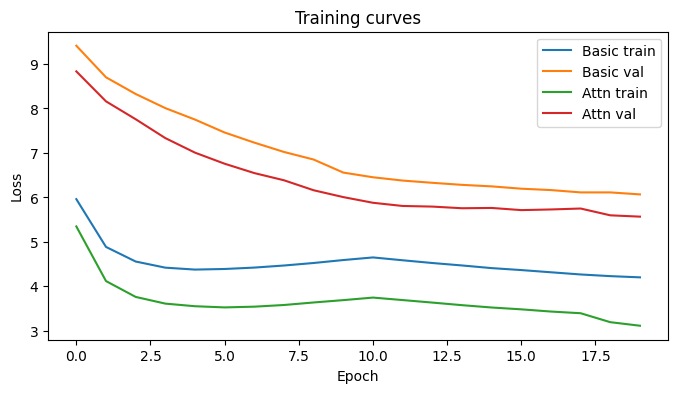

In [12]:
model_basic.load_state_dict(torch.load(f"{DRIVE_DIR}/seq2seq_basic_best.pt", map_location=DEVICE))
model_attn.load_state_dict(torch.load(f"{DRIVE_DIR}/seq2seq_attn_best.pt", map_location=DEVICE))

plt.figure(figsize=(8, 4))
plt.plot(hist_basic["train"], label="Basic train")
plt.plot(hist_basic["val"], label="Basic val")
plt.plot(hist_attn["train"], label="Attn train")
plt.plot(hist_attn["val"], label="Attn val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title("Training curves"); plt.show()


In [13]:
MAX_GEN_LEN = 60

def blocked(seq, n):
    if n <= 1 or len(seq) < n - 1:
        return set()
    ctx = tuple(seq[-(n - 1):])
    return {seq[j + n - 1] for j in range(len(seq) - (n - 1))
            if tuple(seq[j:j + n - 1]) == ctx and j + n - 1 < len(seq)}

def block_pred(pred, out):
    for t in blocked(out, 2) | blocked(out, 3):
        pred[0, t] = -1e9
    return pred

@torch.no_grad()
def translate_basic(sentence):
    model_basic.eval()
    src = torch.tensor([encode(sp_en, sentence, MAX_SRC_LEN)]).to(DEVICE)
    _, h, c = model_basic.encoder(src, torch.tensor([src.shape[1]]))
    tok = torch.tensor([SOS]).to(DEVICE)
    out = []
    for _ in range(MAX_GEN_LEN):
        pred, h, c = model_basic.decoder(tok, h, c)
        pred = block_pred(pred, out)
        tok = pred.argmax(1)
        if tok.item() == EOS:
            break
        out.append(tok.item())
    return sp_am.decode(out)

@torch.no_grad()
def translate_attn(sentence, return_attn=False):
    model_attn.eval()
    src = torch.tensor([encode(sp_en, sentence, MAX_SRC_LEN)]).to(DEVICE)
    eo, h, c = model_attn.encoder(src, torch.tensor([src.shape[1]]))
    mask = model_attn.mask(src)
    tok = torch.tensor([SOS]).to(DEVICE)
    out = []; attn = []
    for _ in range(MAX_GEN_LEN):
        pred, h, c, w = model_attn.decoder(tok, h, c, eo, mask)
        pred = block_pred(pred, out)
        tok = pred.argmax(1)
        attn.append(w.squeeze(0).cpu().numpy())
        if tok.item() == EOS:
            break
        out.append(tok.item())
    text = sp_am.decode(out)
    if return_attn:
        pieces = ["<sos>"] + sp_en.encode(sentence, out_type=str) + ["<eos>"]
        return text, np.array(attn)[:len(out)], pieces
    return text

for s in ["I am going to the university.", "Good morning.", "Thank you very much."]:
    print(f"EN: {s}")
    print(f"B : {translate_basic(s)}")
    print(f"A : {translate_attn(s)}\n")


EN: I am going to the university.
B : እኔ ነገ ወደ ዩኒቨርሲቲ እሄዳለሁ።
A : እኔ እኔ ወደ ዩኒቨርሲቲ እሄዳለሁ።

EN: Good morning.
B : በየቀኑ ጠዋት ጠዋት ላይ
A : ማለዳ ላይ

EN: Thank you very much.
B : በጣም ጥቂት ሁኔታ
A : በጣም ደስ ይበላችሁ።



In [14]:
def gen_all(fn, srcs):
    t0 = time.time()
    h = [fn(s) for s in srcs]
    return h, (time.time() - t0) / max(len(srcs), 1) * 1000

hyps_b, ms_b = gen_all(translate_basic, te_s)
hyps_a, ms_a = gen_all(translate_attn, te_s)

comparison = pd.DataFrame([
    {"Model": "Basic Seq2Seq",
     "BLEU": round(sacrebleu.corpus_bleu(hyps_b, [te_t]).score, 2),
     "chrF": round(sacrebleu.corpus_chrf(hyps_b, [te_t]).score, 2),
     "Train (s)": round(time_basic, 1),
     "Infer (ms/sent)": round(ms_b, 1),
     "Params": n_params(model_basic)},
    {"Model": "Attention Seq2Seq",
     "BLEU": round(sacrebleu.corpus_bleu(hyps_a, [te_t]).score, 2),
     "chrF": round(sacrebleu.corpus_chrf(hyps_a, [te_t]).score, 2),
     "Train (s)": round(time_attn, 1),
     "Infer (ms/sent)": round(ms_a, 1),
     "Params": n_params(model_attn)},
])
display(comparison)

def repeat_rate(hyps):
    def has_rep(t):
        w = t.split()
        return any(len(set(w[i:i + 2])) == 1 for i in range(len(w) - 1))
    return sum(has_rep(h) for h in hyps) / len(hyps)

print(f"Repeat rate — Basic {repeat_rate(hyps_b):.1%} | Attn {repeat_rate(hyps_a):.1%}")


,Model,BLEU,chrF,Train (s),Infer (ms/sent),Params
0,Basic Seq2Seq,15.78,24.15,10183.5,10.9,15556416
1,Attention Seq2Seq,25.06,33.57,25009.7,24.0,23274304


Repeat rate — Basic 51.5% | Attn 45.4%


In [15]:
random.seed(SEED)
idxs = random.sample(range(len(te_s)), min(15, len(te_s)))
qual_df = pd.DataFrame([{
    "Source (EN)": te_s[i],
    "Reference (AM)": te_t[i],
    "Basic Seq2Seq": hyps_b[i],
    "Attention Seq2Seq": hyps_a[i],
} for i in idxs])
qual_df.to_csv(f"{WORKDIR}/qualitative_comparison.csv", index=False)
display(qual_df)


,Source (EN),Reference (AM),Basic Seq2Seq,Attention Seq2Seq
0,The barge companies do not own the Missouri ri...,ሚዙሪን በጋራ ለመጠቀም መንገድ መፈለግ አለብን።,የፔንታጐንሣሪያዎች,የንግድ መርከብ ድርጅቶች በአ ወንዝ ወንዝ ላይ ወንዝ አይደሉም።
1,"you mountains and all you hills,",እናንተ ተራሮችና ኮረብቶች ሁሉ፣,ተራሮችንና በውስጧ ተራሮች ሁሉ፣ በዙሪያዋ ያሉትንም ሁሉ,እናንተ ተራሮችና ኮረብቶች ሁሉ፣ ኮረብታ ሁሉ፣
2,"Allah ! there is no God but he , the Lord of t...",አላህ ከርሱ ሌላ አምላክ የለም ፡ ፡ የታላቁ ዐርሽ ( ዙፋን ) ጌታ ነው...,አላህ ከርሱ ሌላ አምላክ የለም ፡ ፡ የታላቁ ዐርሽ ጌታ ዙፋን ፡ ጌታ ነው ፡,አላህ ከርሱ ሌላ አምላክ የለም ፡ ፡ የታላቁ ዐርሽ ( ዙፋን ) ጌታ ነው...
3,"Every morning, you are going to the hospital.",በየቀኑ ጠዋት አንተ ወደ ሆስፒታል ትሄዳለህ።,በየቀኑ ጠዋት አንተ ወደ ሆስፒታል ትሄዳለህ።,በየቀኑ ጠዋት አንተ ወደ ሆስፒታል ትሄዳለህ።
4,"7 moses' successor, joshua, also witnessed jeh...",7 በሙሴ እግር የተተካው ኢያሱም ቢሆን ያህዌ በግብጽና በምድረ በዳ ያከና...,7 ሙሴ በሙሴ ዘመን ያህዌ ሙሴንና እስራኤላውያን ከግብጽ ምድር ላይና በም...,7 ሙሴ፣ ኢያሱ፣ ኢዮአብና በግብጽ ያህዌ በግብጽ ያህዌን በማፈራ የያህዌን...
5,"true, in today's world modesty is anything but...",እውነት ነው፣ በዛሬው አለም ውስጥ ትህትና ወይም ልክን ማወቅ ከፍ ተደርጎ...,እርግጥ ነው፣ በመጽሃፍ ቅዱስ ውስጥ የሚገኙ የያህዌ ምስክሮች አለም ውስጥ...,እርግጥ ነው፣ በዛሬው ጊዜ በአለም ላይ ያለው አለም የሚናገሩት ነገር ግን...
6,21. (a) we should be determined to do what?,21. (ሃ) ቁርጥ ውሳኔያችን ምን መሆን ይኖርበታል?,21. (ሃ) ቁርጥ ውሳኔያችን ምን ማድረግ ይኖርብናል?,21. (ሃ) ይህን ማድረግ ያለብን ቁርጥ ውሳኔ ማድረግ ይኖርብናል?
7,"But the other woman said: “No, my son is the l...",ሆኖም ሌላኛዋ ሴት “በፍጹም፣ በሕይወት ያለው የእኔ ልጅ ነው፤ የሞተው የ...,ሴትየዋዋም “ “ጌታዬ ሆይ፣ ልጄ ነህ! ልጄ ልጅ ነህ፤ ልጅ ልጅም ልጅ” ...,ሌላ ሴት ግን እንዲህ አለች፦ “እኔ ልጅ ልጄ ነው፤ ሕያው ነኝ!” የሚል ...
8,Rally against them your cavalry and those on f...,« ከእነሱ የቻልከውንም ሰው በድምጽህ አታል ፡ ፡ በእነሱም ላይ በፈረሰኞ...,« የወንዶችንም የኢብራሂምንና የኢስሐቅን ፣ የያዕቆብንም ( ልጆቻችሁን )...,« ከእነሱንም ላይ ቃል ( እግ ) » በመለታቸው ላይ ፡ ፡ በገንዘቦቻቸው...
9,she was a great help.,ሎሊ ከፍተኛ እርዳታ አበርክታልኛለች።,ይህች እህት በጣም በጣም ነበረች። ነበረች።,እሷ እህት በጣም አስቸጋሪ ነበር።



--- Basic (n=26451) ---
  Repeated words : 13630  (51.5%)
  Empty          : 0  (0.0%)
  Too short      : 943  (3.6%)
  Too long       : 925  (3.5%)
  Identity copy  : 0  (0.0%)
  Latin leak     : 54  (0.2%)
  Corr(src_len,BLEU): -0.157

--- Attention (n=26451) ---
  Repeated words : 11998  (45.4%)
  Empty          : 0  (0.0%)
  Too short      : 549  (2.1%)
  Too long       : 972  (3.7%)
  Identity copy  : 0  (0.0%)
  Latin leak     : 3  (0.0%)
  Corr(src_len,BLEU): -0.065


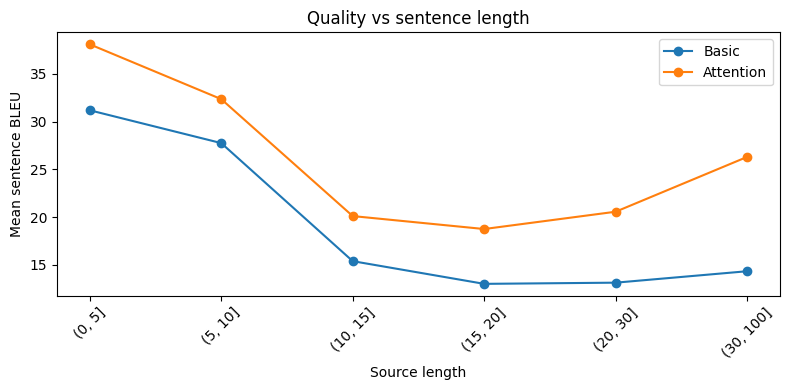

In [16]:
def sent_bleu(h, r):
    return sacrebleu.sentence_bleu(h, [r]).score

def has_repeat(text, n=2):
    w = text.split()
    return any(len(set(w[i:i + n])) == 1 for i in range(len(w) - n + 1))

def length_ratio(h, r):
    rl = len(r.split())
    return len(h.split()) / rl if rl else 0.0

def has_latin_leak(h):
    return bool(re.search(r"[A-Za-z]{3,}", h))

def build_err_df(srcs, refs, hyps):
    rows = []
    for s, r, h in zip(srcs, refs, hyps):
        rows.append({
            "source": s, "reference": r, "hypothesis": h,
            "sentence_bleu": round(sent_bleu(h, r), 2),
            "src_len": len(s.split()),
            "repeated_words": has_repeat(h, 2),
            "empty_output": len(h.strip()) == 0,
            "too_short": length_ratio(h, r) < 0.5,
            "too_long": length_ratio(h, r) > 1.5,
            "identity_copy": h.strip().lower() == s.strip().lower(),
            "latin_leak": has_latin_leak(h),
        })
    return pd.DataFrame(rows)

err_b = build_err_df(te_s, te_t, hyps_b)
err_a = build_err_df(te_s, te_t, hyps_a)

def summarize(df, name):
    n = len(df)
    print(f"\n--- {name} (n={n}) ---")
    print(f"  Repeated words : {df.repeated_words.sum()}  ({df.repeated_words.mean():.1%})")
    print(f"  Empty          : {df.empty_output.sum()}  ({df.empty_output.mean():.1%})")
    print(f"  Too short      : {df.too_short.sum()}  ({df.too_short.mean():.1%})")
    print(f"  Too long       : {df.too_long.sum()}  ({df.too_long.mean():.1%})")
    print(f"  Identity copy  : {df.identity_copy.sum()}  ({df.identity_copy.mean():.1%})")
    print(f"  Latin leak     : {df.latin_leak.sum()}  ({df.latin_leak.mean():.1%})")
    corr = df[["src_len", "sentence_bleu"]].corr().iloc[0, 1]
    print(f"  Corr(src_len,BLEU): {corr:+.3f}")

summarize(err_b, "Basic")
summarize(err_a, "Attention")
err_b.to_csv(f"{WORKDIR}/error_analysis_basic.csv", index=False)
err_a.to_csv(f"{WORKDIR}/error_analysis_attn.csv", index=False)

plt.figure(figsize=(8, 4))
bins = [0, 5, 10, 15, 20, 30, 100]
for df, label in [(err_b, "Basic"), (err_a, "Attention")]:
    b = df.groupby(pd.cut(df["src_len"], bins=bins), observed=True)["sentence_bleu"].mean()
    plt.plot(b.index.astype(str), b.values, marker="o", label=label)
plt.xticks(rotation=45)
plt.xlabel("Source length"); plt.ylabel("Mean sentence BLEU")
plt.title("Quality vs sentence length"); plt.legend(); plt.tight_layout()
plt.savefig(f"{WORKDIR}/quality_vs_length.png", dpi=150, bbox_inches="tight")
plt.show()


Registered Ethiopic font: /usr/share/fonts/truetype/noto/NotoSansEthiopic-Bold.ttf


/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 60 (<) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 115 (s) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 62 (>) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 73 (I) missing from font(s) No

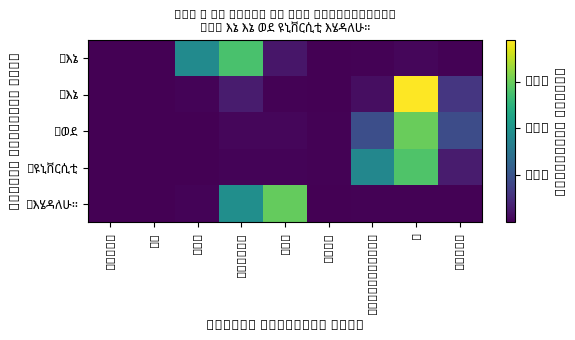

/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 60 (<) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 115 (s) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 62 (>) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 116 (t) missing from font(s) N

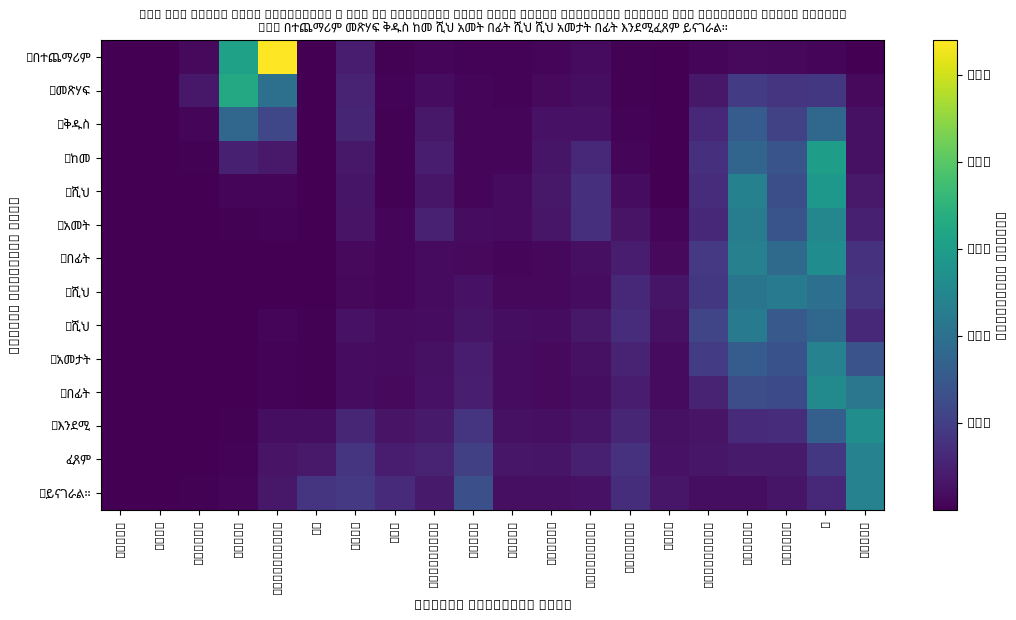

/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 60 (<) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 115 (s) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 111 (o) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 62 (>) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Noto Sans Ethiopic.
  plt.tight_layout()
/tmp/ipykernel_2751/2438732698.py:30: UserWarning: Glyph 73 (I) missing from font(s) No

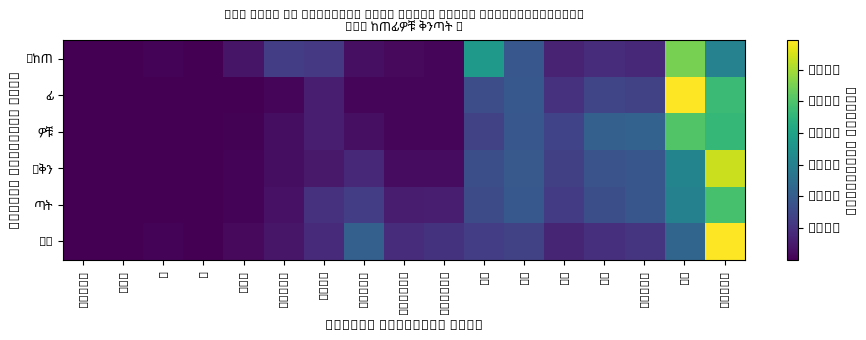

In [17]:
!apt-get install -y -qq fonts-noto-core > /dev/null 2>&1
import matplotlib.font_manager as fm
eth = [f for f in fm.findSystemFonts() if "ethiopic" in f.lower()]
if eth:
    for f in eth:
        fm.fontManager.addfont(f)
    plt.rcParams["font.family"] = "Noto Sans Ethiopic"
    print("Registered Ethiopic font:", eth[0])
else:
    print("No Ethiopic font found — Amharic may render as boxes")

def plot_attention(sentence, save_as=None):
    translation, attn, src_pieces = translate_attn(sentence, return_attn=True)
    if attn.size == 0:
        print(f"Empty output: {sentence!r}")
        return
    tgt_pieces = sp_am.encode(translation, out_type=str)
    n = min(len(tgt_pieces), attn.shape[0])
    attn = attn[:n]; tgt_pieces = tgt_pieces[:n]
    fig, ax = plt.subplots(figsize=(max(6, len(src_pieces) * 0.55), max(3.5, n * 0.45)))
    im = ax.imshow(attn, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(src_pieces)))
    ax.set_xticklabels(src_pieces, rotation=90, fontsize=9)
    ax.set_yticks(range(len(tgt_pieces)))
    ax.set_yticklabels(tgt_pieces, fontsize=9)
    ax.set_xlabel("Source subwords (EN)")
    ax.set_ylabel("Target subwords (AM)")
    fig.colorbar(im, ax=ax, label="Attention weight")
    ax.set_title(f"EN: {sentence}\nAM: {translation}", fontsize=9)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches="tight")
    plt.show()

for k, s in enumerate([
    "I am going to the university.",
    te_s[0] if len(te_s) > 0 else "Good morning.",
    te_s[1] if len(te_s) > 1 else "Thank you very much.",
], 1):
    plot_attention(s, save_as=f"{WORKDIR}/attention_example_{k}.png")


In [18]:
worksheet = err_a.sort_values("sentence_bleu").head(20).copy()
worksheet["error_category"] = ""
worksheet["explanation"] = ""
display(worksheet[["source", "reference", "hypothesis",
                   "sentence_bleu", "error_category", "explanation"]])
worksheet.to_csv(f"{WORKDIR}/error_worksheet.csv", index=False)
print(f"Worksheet saved to {WORKDIR}/error_worksheet.csv")
print("Fill in error_category + explanation, then paste into the report.")


,source,reference,hypothesis,sentence_bleu,error_category,explanation
9214,now the earth shook violently.,ድንገት ምድሪቱ በሃይል ተናወጠች።,ምድር ምድር ያለምናወጥ ጸጥታች።,0.0,,
19265,the nears and dears have been busy here and th...,ወዳጅ ዘመድ ተፍ ተፍ እያለ ዝግጅት አጧጡፏል።,በአዲሱ ጉባኤና ተረጋግተው የነበሩት ሲሆን በአሁኑ ጊዜ ተዛዥቷል።,0.0,,
19271,you must also make them known to your sons and...,እነዚህንም ለልጆቻችሁና ለልጅ ልጆቻችሁ ንገሯቸው።,እናንተም ለል የልጅ ልጆችህና የልጅ የልጅነት እንዲሆኑ እንዲሆኑ አድርገሃል።,0.0,,
19277,When we make a defense before everyone who dem...,ስለ ተስፋችን፣ ምክንያት እንድናቀርብ ለሚጠይቀን ሰው መልስ የምንሰጠው በ...,እኛም ለእኛልንልን ለእኛ ስንሰብክልን ስንን ስንሰማን ባሕሩ ስን ስንጥርና...,0.0,,
2130,"And its mixture is of Tasneem ,",መበረዣውም ከተስኒም ነው ፡ ፡,በውስጧምዣውም ኾና የምትፈትረው ፤ ( በራሱ የተመካ ) ፤,0.0,,
2133,Space Bar,ደረጃን ለኩ,የግብጽ አና,0.0,,
2134,"But Nassar Hussein Musawi, a schoolteacher, di...",ነገር ግን ሁሴን ሙሳዊ የተባለ የትምህርት ቤት አስተማሪ እንዲህ ሲል ተቃ...,«ከዚያው ፕሬስ ፎቶግራር ከጠየቁ በፊት፣ ከሥራው ጋር የሚገናኙት» በማለት...,0.0,,
13697,no doubt they were touched to see how the yout...,ይህ ወጣት የጉባኤውን አባላት ለማነጽና ለማበረታታት የሚያደርገውን ጥረት ...,ወጣቶቹ ወጣቶች ምን ያህል እንደሚወዱ በዙሪያው ያሉትን ወጣቶች በዙሪያው ...,0.0,,
13702,they knew that they would die if they withdrew...,አፍቃሪ የሆነውን አምላክ እንክብካቤ ካጡ እንደሚሞቱ ያውቁ ነበር።,የአምላክን የአምላክን ሞገስ ማግኘት እንደማይችሉ ሲሰማቸው የሚያደርጉትን ሰዎች,0.0,,
13705,"Turkey, which fears northern Iraqi Kurds may d...",የኢራቅ ኩርዶች መገንጠል ለ15 ዓመታት ያህል ለራስ-ገዝ ሲዋጉ የነበሩትን...,በኢራቅ ላይ ቱርክ በኢራቅ ውስጥ እንዲሁ በሳዳም ሁሴን ጦርነቱን በመርዳት...,0.0,,


Worksheet saved to /content/nmt_project/error_worksheet.csv
Fill in error_category + explanation, then paste into the report.


In [19]:
PIPELINE_LINES = [
    "import json, torch, torch.nn as nn, torch.nn.functional as F",
    "import sentencepiece as spm",
    'DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")',
    "",
    "class Encoder(nn.Module):",
    "    def __init__(self, v, e, h, n, d, pad):",
    "        super().__init__()",
    "        self.emb = nn.Embedding(v, e, padding_idx=pad)",
    "        self.rnn = nn.LSTM(e, h, n, batch_first=True, dropout=d if n > 1 else 0)",
    "        self.drop = nn.Dropout(d)",
    "    def forward(self, src, lens):",
    "        x = self.drop(self.emb(src))",
    "        p = nn.utils.rnn.pack_padded_sequence(x, lens.cpu(), batch_first=True, enforce_sorted=False)",
    "        out, (h, c) = self.rnn(p)",
    "        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)",
    "        return out, h, c",
    "",
    "class Attention(nn.Module):",
    "    def __init__(self, h):",
    "        super().__init__()",
    "        self.attn = nn.Linear(h * 2, h)",
    "        self.v = nn.Linear(h, 1, bias=False)",
    "    def forward(self, dh, eo, mask):",
    "        S = eo.shape[1]",
    "        hr = dh.unsqueeze(1).repeat(1, S, 1)",
    "        e = torch.tanh(self.attn(torch.cat((hr, eo), dim=2)))",
    "        return F.softmax(self.v(e).squeeze(2).masked_fill(mask == 0, -1e10), dim=1)",
    "",
    "class DecoderAttn(nn.Module):",
    "    def __init__(self, v, e, h, n, d, pad):",
    "        super().__init__()",
    "        self.attention = Attention(h)",
    "        self.emb = nn.Embedding(v, e, padding_idx=pad)",
    "        self.rnn = nn.LSTM(e + h, h, n, batch_first=True, dropout=d if n > 1 else 0)",
    "        self.fc = nn.Linear(h * 2 + e, v)",
    "        self.drop = nn.Dropout(d)",
    "    def forward(self, tok, h, c, eo, mask):",
    "        x = self.drop(self.emb(tok.unsqueeze(1)))",
    "        w = self.attention(h[-1], eo, mask)",
    "        ctx = torch.bmm(w.unsqueeze(1), eo)",
    "        out, (h, c) = self.rnn(torch.cat((x, ctx), dim=2), (h, c))",
    "        out, ctx, x = out.squeeze(1), ctx.squeeze(1), x.squeeze(1)",
    "        return self.fc(torch.cat((out, ctx, x), dim=1)), h, c, w",
    "",
    "class Translator:",
    "    def __init__(self, artifact_dir):",
    '        with open(f"{artifact_dir}/config.json") as f:',
    "            self.cfg = json.load(f)",
    "        c = self.cfg",
    '        self.pad, self.sos, self.eos = c["pad"], c["sos"], c["eos"]',
    '        self.sp_en = spm.SentencePieceProcessor(model_file=f"{artifact_dir}/en.model")',
    '        self.sp_am = spm.SentencePieceProcessor(model_file=f"{artifact_dir}/am.model")',
    '        enc = Encoder(c["src_vocab"], c["emb_dim"], c["hid_dim"], c["n_layers"], c["dropout"], self.pad)',
    '        dec = DecoderAttn(c["tgt_vocab"], c["emb_dim"], c["hid_dim"], c["n_layers"], c["dropout"], self.pad)',
    "        self.encoder = enc.to(DEVICE)",
    "        self.decoder = dec.to(DEVICE)",
    '        st = torch.load(f"{artifact_dir}/model.pt", map_location=DEVICE)',
    '        self.encoder.load_state_dict({k.replace("encoder.", "", 1): v for k, v in st.items() if k.startswith("encoder.")})',
    '        self.decoder.load_state_dict({k.replace("decoder.", "", 1): v for k, v in st.items() if k.startswith("decoder.")})',
    "        self.encoder.eval()",
    "        self.decoder.eval()",
    "    def _prep(self, text):",
    '        ids = self.sp_en.encode(text.strip(), out_type=int)[: self.cfg["max_src_len"] - 2]',
    "        return [self.sos] + ids + [self.eos]",
    "    @staticmethod",
    "    def _blocked(seq, n):",
    "        if n <= 1 or len(seq) < n - 1:",
    "            return set()",
    "        ctx = tuple(seq[-(n - 1):])",
    "        return {seq[j + n - 1] for j in range(len(seq) - (n - 1))",
    "                if tuple(seq[j:j + n - 1]) == ctx and j + n - 1 < len(seq)}",
    "    @torch.no_grad()",
    "    def translate(self, text):",
    "        src = torch.tensor([self._prep(text)]).to(DEVICE)",
    "        eo, h, c = self.encoder(src, torch.tensor([src.shape[1]]))",
    "        mask = src != self.pad",
    "        tok = torch.tensor([self.sos]).to(DEVICE)",
    "        out = []",
    '        for _ in range(self.cfg["max_gen_len"]):',
    "            pred, h, c, _ = self.decoder(tok, h, c, eo, mask)",
    "            for t in self._blocked(out, 2) | self._blocked(out, 3):",
    "                pred[0, t] = -1e9",
    "            tok = pred.argmax(1)",
    "            if tok.item() == self.eos:",
    "                break",
    "            out.append(tok.item())",
    "        return self.sp_am.decode(out)",
]

APP_LINES = [
    "from fastapi import FastAPI",
    "from pydantic import BaseModel",
    "from pipeline import Translator",
    'app = FastAPI(title="EN -> AM NMT")',
    'translator = Translator(artifact_dir=".")',
    "class Req(BaseModel):",
    "    text: str",
    "class Res(BaseModel):",
    "    translation: str",
    '@app.post("/translate", response_model=Res)',
    "def translate(r: Req):",
    '    return {"translation": translator.translate(r.text)}',
    '@app.get("/health")',
    "def health():",
    '    return {"status": "ok"}',
]

import shutil
DEPLOY = f"{WORKDIR}/deploy"
shutil.copy(f"{DRIVE_DIR}/seq2seq_attn_best.pt", f"{DEPLOY}/model.pt")
shutil.copy(f"{WORKDIR}/tokenizer/en.model", f"{DEPLOY}/en.model")
shutil.copy(f"{WORKDIR}/tokenizer/am.model", f"{DEPLOY}/am.model")
with open(f"{DEPLOY}/config.json", "w") as f:
    json.dump({"emb_dim": EMB_DIM, "hid_dim": HID_DIM, "n_layers": N_LAYERS,
               "dropout": DROPOUT, "src_vocab": SRC_VOCAB, "tgt_vocab": TGT_VOCAB,
               "max_src_len": MAX_SRC_LEN, "max_gen_len": MAX_GEN_LEN,
               "pad": PAD, "unk": UNK, "sos": SOS, "eos": EOS}, f, indent=2)
open(f"{DEPLOY}/pipeline.py", "w").write("\n".join(PIPELINE_LINES))
open(f"{DEPLOY}/app.py", "w").write("\n".join(APP_LINES))
open(f"{DEPLOY}/requirements.txt", "w").write("torch\nsentencepiece\nfastapi\nuvicorn\n")

shutil.copytree(DEPLOY, f"{DRIVE_DIR}/deploy", dirs_exist_ok=True)
print("Deploy artifacts on Drive:", f"{DRIVE_DIR}/deploy")
print(sorted(os.listdir(f"{DRIVE_DIR}/deploy")))

Deploy artifacts on Drive: /content/drive/MyDrive/nmt_project_checkpoints/deploy
['am.model', 'app.py', 'config.json', 'en.model', 'model.pt', 'pipeline.py', 'requirements.txt']


In [20]:
sys.path.insert(0, f"{WORKDIR}/deploy")
import gradio as gr
from pipeline import Translator
tr = Translator(f"{WORKDIR}/deploy")

demo = gr.Interface(
    fn=tr.translate,
    inputs=gr.Textbox(label="English", placeholder="I am going to the university."),
    outputs=gr.Textbox(label="Amharic"),
    title="English -> Amharic NMT",
    description="Attention Seq2Seq LSTM",
)
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f1f3d7267a82e74cc0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
import shutil
PKG = f"{WORKDIR}/submission_package"
shutil.rmtree(PKG, ignore_errors=True)
os.makedirs(f"{PKG}/results", exist_ok=True)
shutil.copytree(f"{WORKDIR}/checkpoints", f"{PKG}/checkpoints")
shutil.copytree(f"{WORKDIR}/tokenizer", f"{PKG}/tokenizer")
shutil.copytree(f"{WORKDIR}/deploy", f"{PKG}/deploy")
comparison.to_csv(f"{PKG}/results/model_comparison.csv", index=False)
qual_df.to_csv(f"{PKG}/results/qualitative_comparison.csv", index=False)
err_b.to_csv(f"{PKG}/results/error_analysis_basic.csv", index=False)
err_a.to_csv(f"{PKG}/results/error_analysis_attn.csv", index=False)
worksheet.to_csv(f"{PKG}/results/error_worksheet.csv", index=False)
for f in ["quality_vs_length.png", "attention_example_1.png",
          "attention_example_2.png", "attention_example_3.png"]:
    src = f"{WORKDIR}/{f}"
    if os.path.exists(src):
        shutil.copy(src, f"{PKG}/results/{f}")
with open(f"{PKG}/README.md", "w") as f:
    f.write(f"# EN->AM NMT submission\n\n{comparison.to_markdown(index=False)}\n")
zip_path = "/content/nmt_submission_package.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(PKG):
        for file in files:
            full = os.path.join(root, file)
            zf.write(full, os.path.relpath(full, PKG))
print(f"Package: {zip_path}")
shutil.copy(zip_path, f"{DRIVE_DIR}/nmt_submission_package.zip")
from google.colab import files
files.download(zip_path)


Package: /content/nmt_submission_package.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Dataset Source and License Documentation

## Dataset Source and License Documentation

The parallel English–Amharic data used in this project was collected from publicly available sources.

| Dataset / Source | Language Pair | Role in Project | License |
|---|---|---|---|
| OPUS-100 | English–Amharic | Parallel translation data | **Document the license stated by the original dataset source before submission.** |
| adtsegaye corpus | English–Amharic | Parallel translation data | **Document the license stated by the original repository before submission.** |
| Gezmu et al. corpus | English–Amharic | Parallel translation data | **Document the license stated by the original publication/repository before submission.** |

**Important:** The license information must be taken from the original dataset/repository source and should not be guessed. The final report should include the source URL/reference and the exact license name for every dataset used.


# Data Split Documentation

## Data Split Documentation

After cleaning and filtering the parallel corpus, the data is divided into training, validation, and test sets.

- **Training set:** used for model parameter learning.
- **Validation set:** used during training for model selection and monitoring.
- **Test set:** kept separate for final evaluation.

The test set is not used to train the models. This separation allows the final BLEU, chrF, loss, and timing results to be evaluated on unseen sentence pairs.


# Required Training Configuration

## Required Training Configuration

The main training configuration used for both Seq2Seq models is:

| Configuration | Value |
|---|---|
| Embedding size | 256 |
| Hidden units | 512 |
| Number of LSTM layers | 2 |
| Batch size | 64 |
| Learning rate | 0.001 |
| Optimizer | Adam |
| Number of epochs | 20 |
| Loss function | CrossEntropyLoss |

The same general training configuration is used for the Basic Seq2Seq LSTM and Attention-Based Seq2Seq LSTM so that their performance can be compared fairly.


# Test Loss Evaluation

## Test Loss Evaluation

The project requirements include **test loss** in addition to BLEU and chrF. The final comparison should report the loss calculated on the held-out test set for both models.

> Run the test-loss evaluation cell below after the models and `test_loader` are available, then use the resulting values in the final comparison table.


# Required Error Categories

## Required Error Categories

For the final error analysis, examine examples from both models using the following categories required by the project:

1. Incorrect word order
2. Missing words
3. Additional words
4. Repeated words
5. Incorrect morphology
6. Named-entity errors
7. Unknown or rare words
8. Long-sentence translation errors

For each selected example, record the English source, reference Amharic translation, model output, error category, and a short explanation.


# Attention Interpretation

## Interpretation of Attention Visualizations

For selected attention heatmaps, explain what the attention-based decoder is focusing on during generation.

For each example, discuss:
- which source words receive relatively high attention,
- which generated Amharic words are associated with those source words,
- whether the alignment appears reasonable,
- and any incorrect or diffuse attention that may explain a translation error.

The heatmap should therefore be accompanied by a short interpretation rather than being presented alone.


# Complete README Requirements

## README Requirements

The final submission README should include:

- Project title and objective
- Group members
- Dataset sources and licenses
- Dataset preprocessing and split
- Model architectures
- Training configuration
- Evaluation metrics and comparison
- Error-analysis summary
- Attention-analysis summary
- Installation instructions
- How to run preprocessing/training/evaluation
- How to launch the Gradio/FastAPI application
- Example English input and Amharic output
- Required dependencies
- Project file/folder structure


In [22]:
# Calculate final test loss for both models
import torch

def calculate_test_loss(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for src, lens, trg in test_loader:
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, lens, trg, 0.0)

            # Ignore <pad> tokens in the target
            output_dim = output.size(-1)
            output = output[:, 1:].reshape(-1, output_dim)
            target = trg[:, 1:].reshape(-1)

            loss = criterion(output, target)
            non_pad = (target != PAD).sum().item()

            total_loss += loss.item() * non_pad
            total_tokens += non_pad

    return total_loss / max(total_tokens, 1)

# Use the same criterion/device already defined in the notebook.
basic_test_loss = calculate_test_loss(model_basic, test_loader, criterion, DEVICE)
attention_test_loss = calculate_test_loss(model_attn, test_loader, criterion, DEVICE)

print(f"Basic Seq2Seq Test Loss: {basic_test_loss:.4f}")
print(f"Attention Seq2Seq Test Loss: {attention_test_loss:.4f}")

Basic Seq2Seq Test Loss: 6.0870
Attention Seq2Seq Test Loss: 5.5816


# Final Assignment Compliance Checklist
-  Public parallel dataset and preprocessing
-  Exact dataset license documented for every source used
-  Basic Seq2Seq + LSTM
-  Attention-Based Seq2Seq + LSTM
-  Required training configuration documented
-  BLEU
-  chrF
-  Final test loss values reported
-  Training time
-  Inference time
-  Number of parameters
-  Comparison table
-  Translation examples: Source → Reference → both model outputs
-  Error-analysis framework
-  Explicit examples for every required error category
-  Attention visualizations
-  Written interpretation of selected attention examples
-  Working Gradio/FastAPI deployment
-  Complete README
-  Final technical report
-  Presentation and live demonstration

